# IBM HR Analytics: Employee Attrition Analysis

## Objective

### The objective of this project is to identify key factors influencing employee attrition and provide actionable recommendations to improve employee retention.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

### The dataset contains employee demographic, compensation, satisfaction, and work-related information for 1,470 employees.

### The objective is to understand the factors influencing employee attrition and identify areas where the organization can improve employee retention.

In [3]:
df = pd.read_csv(r"C:\Users\Vidhi\Desktop\HR Attrition Analysis\Data\WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.shape

(1470, 35)

In [5]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [6]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

## Data Cleaning

### Before performing analysis, the dataset was checked for data quality issues.

### The following checks were performed:

#### - Missing value analysis
#### - Duplicate record analysis
#### - Data type validation
#### - Removal of irrelevant columns

### The following columns were removed as they do not contribute to attrition analysis:

#### - EmployeeCount
#### - EmployeeNumber
#### - Over18
#### - StandardHours

In [8]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [13]:
df_clean=df.copy()

In [14]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [15]:
columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

df_clean = df_clean.drop(columns=columns_to_drop)

In [16]:
df_clean.shape

(1470, 31)

In [17]:
df_clean.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

## Exploratory Data Analysis (EDA)

### The objective of this analysis is to identify factors associated with employee attrition.

### The following areas were analyzed:

#### - Overall Attrition Rate
#### - Overtime vs Attrition
#### - Department vs Attrition
#### - Salary vs Attrition
#### - Job Satisfaction vs Attrition
#### - Work-Life Balance vs Attrition
#### - Age vs Attrition
#### - Years at Company vs Attrition

In [18]:
df_clean['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [19]:
df_clean['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [20]:
pd.crosstab(df_clean['OverTime'],
            df_clean['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [21]:
127 / (289 + 127) * 100

30.528846153846157

In [22]:
110 / (944 + 110) * 100

10.436432637571158

In [23]:
pd.crosstab(df_clean['Department'],
            df_clean['Attrition'])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [24]:
df_clean['Department'].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [25]:
pd.crosstab(df_clean['Department'],
            df_clean['Attrition'],
            normalize='index') * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [26]:
df_clean.groupby('Attrition')['MonthlyIncome'].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

In [27]:
pd.crosstab(df_clean['JobSatisfaction'],
            df_clean['Attrition'],
            normalize='index') * 100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [28]:
pd.crosstab(df_clean['WorkLifeBalance'],
            df_clean['Attrition'],
            normalize='index') * 100

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [29]:
df_clean.groupby('Attrition')['Age'].mean()

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

In [30]:
df_clean.groupby('Attrition')['YearsAtCompany'].mean()

Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64

## Data Visualization

### Visualizations were created to better understand attrition patterns and communicate insights effectively.

### The charts below illustrate the relationship between employee attrition and various employee attributes such as overtime, department, salary, job satisfaction, work-life balance, age, and tenure.

<Axes: xlabel='Attrition', ylabel='count'>

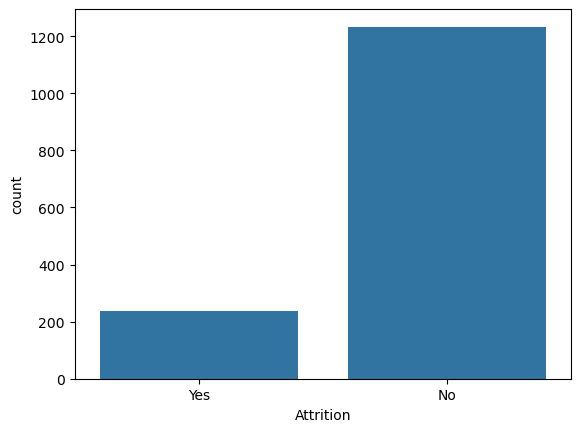

In [31]:
sns.countplot(data=df_clean, x='Attrition')

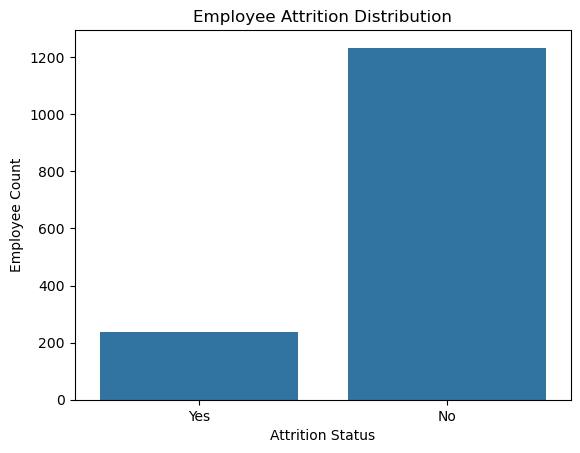

In [33]:
sns.countplot(data=df_clean, x='Attrition')

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition Status')
plt.ylabel('Employee Count')

plt.show()

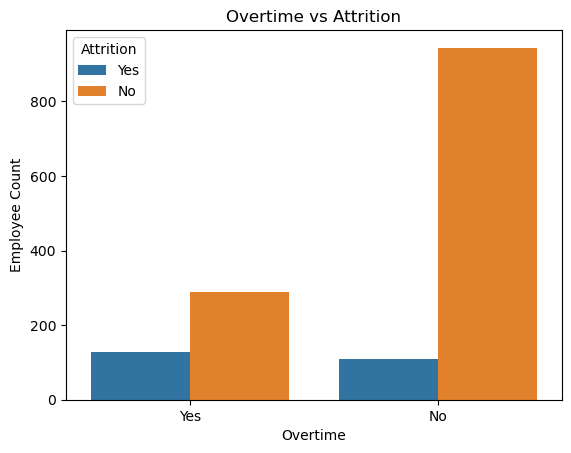

In [34]:
sns.countplot(
    data=df_clean,
    x='OverTime',
    hue='Attrition'
)

plt.title('Overtime vs Attrition')
plt.xlabel('Overtime')
plt.ylabel('Employee Count')

plt.show()

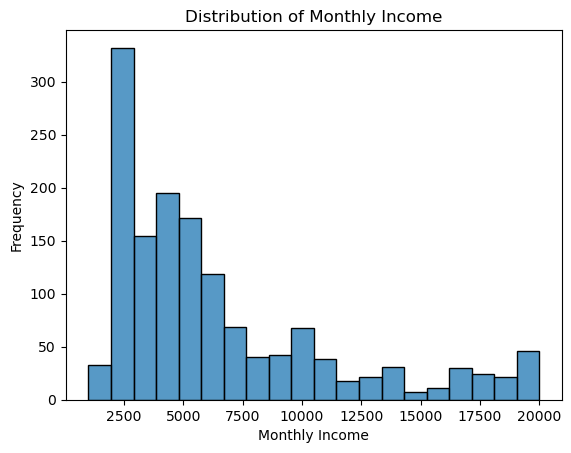

In [35]:
sns.histplot(df_clean['MonthlyIncome'])

plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')

plt.show()

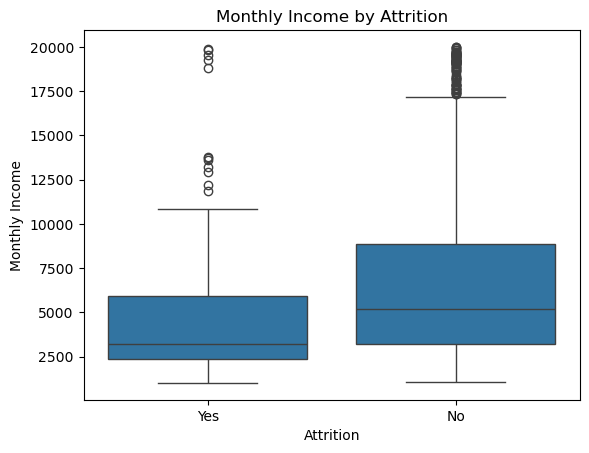

In [36]:
sns.boxplot(data=df_clean,x='Attrition',y='MonthlyIncome')

plt.title('Monthly Income by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')

plt.show()

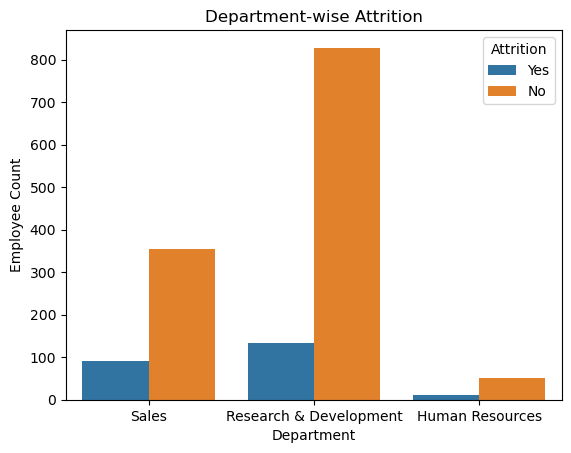

In [37]:
sns.countplot(data=df_clean,x='Department',hue='Attrition')

plt.title('Department-wise Attrition')
plt.xlabel('Department')
plt.ylabel('Employee Count')

plt.show()


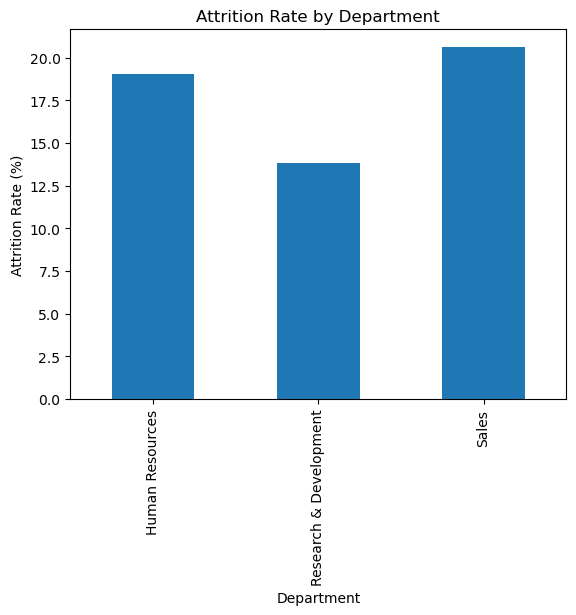

In [38]:
dept_attrition = (pd.crosstab(df_clean['Department'],df_clean['Attrition'],normalize='index') * 100)

dept_attrition['Yes'].plot(kind='bar')

plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate (%)')
plt.show()

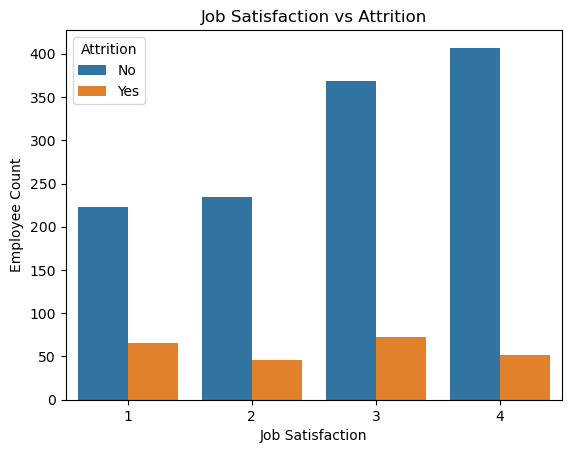

In [39]:
sns.countplot(data=df_clean,x='JobSatisfaction',hue='Attrition')

plt.title('Job Satisfaction vs Attrition')
plt.xlabel('Job Satisfaction')
plt.ylabel('Employee Count')

plt.show()

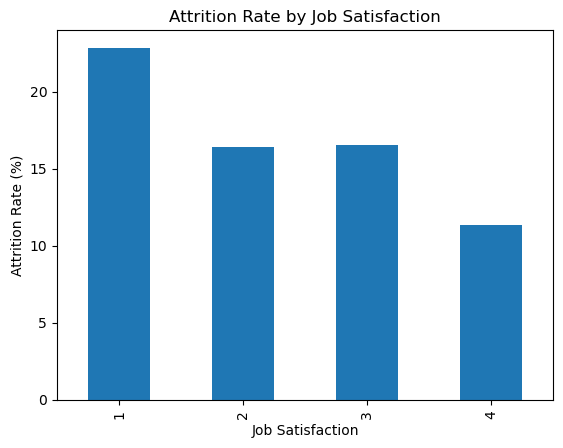

In [44]:
job_attrition = (pd.crosstab(df_clean['JobSatisfaction'],df_clean['Attrition'],normalize='index') * 100)

job_attrition['Yes'].plot(kind='bar')

plt.title('Attrition Rate by Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Attrition Rate (%)')

plt.show()

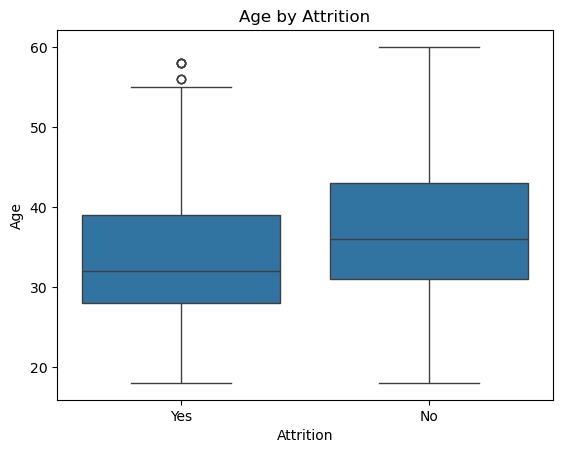

In [45]:
sns.boxplot(data=df_clean, x='Attrition',y='Age')

plt.title('Age by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Age')

plt.show()

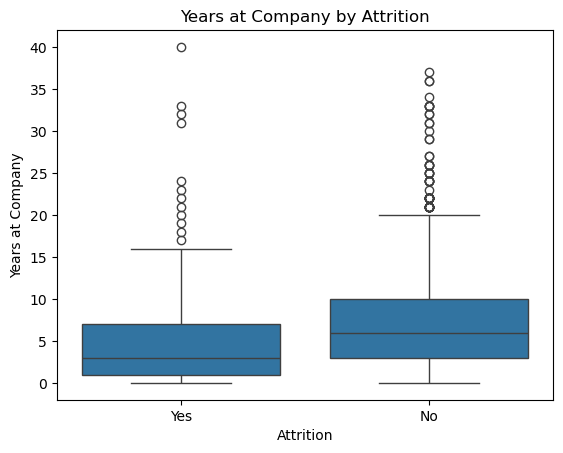

In [47]:
sns.boxplot(data=df_clean,x='Attrition',y='YearsAtCompany')

plt.title('Years at Company by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years at Company')

plt.show()

## Key Findings

### 1. The overall employee attrition rate was 16.12%.

### 2. Employees working overtime experienced significantly higher attrition (30.53%) compared to employees not working overtime (10.44%).

### 3. The Sales department recorded the highest attrition rate among all departments.

### 4. Employees who left the organization had a lower average monthly income compared to employees who stayed.

### 5. Employees with poor work-life balance exhibited the highest attrition rates.

### 6. Employees with lower job satisfaction were more likely to leave the organization.

### 7. Employees who left were generally younger and had spent fewer years at the company.

## Business Recommendations

### Based on the analysis, the following recommendations are proposed:

### 1. Review overtime policies and workload distribution to reduce employee burnout.

### 2. Improve employee work-life balance through flexible work arrangements and wellness initiatives.

### 3. Focus retention efforts on the Sales department, which exhibits the highest attrition rate.

### 4. Evaluate compensation strategies for lower-income employees to improve retention.

### 5. Strengthen onboarding and engagement programs for early-tenure employees.

### 6. Conduct regular employee satisfaction surveys to identify and address workplace concerns proactively.